Part 1: Linear Regression


In [ ]:
# ─────────────────────────────────────────────────────────
# BLOCK 1: Import all libraries
# ─────────────────────────────────────────────────────────

import numpy as np           # math and matrix operations
import pandas as pd          # data handling
import matplotlib.pyplot as plt  # all plots
import time                  # to measure how long each method takes
import warnings
warnings.filterwarnings('ignore')

# Set a fixed random seed so results are reproducible
np.random.seed(42)

print("All libraries imported successfully.")

All libraries imported successfully.


In [ ]:
# ─────────────────────────────────────────────────────────
# BLOCK 2: Load the Housing Dataset
# ─────────────────────────────────────────────────────────

# We use the Boston Housing dataset from a public GitHub URL.
# It has 506 rows and 14 columns.
# TARGET column: 'medv' = median house value (in $1000s)
#
# If you have your own Kaggle CSV, replace this block with:
#   df = pd.read_csv("your_file.csv")

url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df = pd.read_csv(url)

print("Dataset shape:", df.shape)
print("\nColumn names:", list(df.columns))
print("\nFirst 5 rows:")
print(df.head())
print("\nBasic statistics:")
print(df.describe().round(2))

Dataset shape: (506, 14)

Column names: ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat', 'medv']

First 5 rows:
      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  

Basic statistics:
         crim      zn   indus    chas     nox      rm     age     dis     rad  \
count  506.00  506.00  506.00  506.00  506.00  506.00  506.00  506.00  506.00   
mean     3.61   11.36   11.

In [ ]:
# ─────────────────────────────────────────────────────────
# BLOCK 3: Select Features + Train/Test Split
# ─────────────────────────────────────────────────────────

# ── Which features to use ──
# TARGET: 'medv' (house price we want to predict)
#
# MODEL 1: use only 'rm' (avg number of rooms per house)
#          This is the strongest single predictor of price
#
# MODEL 2: use 7 features
#          crim   = crime rate
#          zn     = residential zone proportion
#          rm     = avg rooms (again, most important)
#          age    = proportion of old houses
#          dis    = distance to employment centres
#          tax    = property tax rate
#          lstat  = % lower status population (strong negative effect)

feature_m1 = 'rm'
features_m2 = ['crim', 'zn', 'rm', 'age', 'dis', 'tax', 'lstat']
target = 'medv'

# Check for missing values before proceeding
print("Missing values per column:")
print(df[features_m2 + [target]].isnull().sum())

# ── Show correlation with target ──
print("\nCorrelation of features with house price (medv):")
print(df[features_m2 + [target]].corr()[target].round(3))

# ── Manual 80/20 Train/Test Split ──
# Shuffle the data first so the split is random
data = df.sample(frac=1, random_state=42).reset_index(drop=True)

split_idx = int(0.8 * len(data))    # 80% goes to training

train_data = data.iloc[:split_idx]
test_data  = data.iloc[split_idx:]

print(f"\nTraining samples : {len(train_data)}")
print(f"Testing  samples : {len(test_data)}")

# ── Extract raw X and y arrays ──
# Model 1
X_train_raw_m1 = train_data[[feature_m1]].values   # shape: (404, 1)
X_test_raw_m1  = test_data[[feature_m1]].values     # shape: (102, 1)

# Model 2
X_train_raw_m2 = train_data[features_m2].values     # shape: (404, 7)
X_test_raw_m2  = test_data[features_m2].values      # shape: (102, 7)

# Target (house prices)
y_train = train_data[target].values                  # shape: (404,)
y_test  = test_data[target].values                   # shape: (102,)

Missing values per column:
crim     0
zn       0
rm       0
age      0
dis      0
tax      0
lstat    0
medv     0
dtype: int64

Correlation of features with house price (medv):
crim    -0.388
zn       0.360
rm       0.695
age     -0.377
dis      0.250
tax     -0.469
lstat   -0.738
medv     1.000
Name: medv, dtype: float64

Training samples : 404
Testing  samples : 102


In [ ]:
# ─────────────────────────────────────────────────────────
# BLOCK 4: Normalize Data + Define All Core Functions
# ─────────────────────────────────────────────────────────

# ── WHY NORMALIZE? ──
# Features like 'tax' can be 400+ while 'nox' is 0.5
# Gradient descent struggles when features are on different scales
# — the loss surface becomes elongated and GD zig-zags slowly.
# Standardizing (mean=0, std=1) makes GD converge much faster.

def standardize(X_train, X_test):
    """
    Standardise features: subtract mean, divide by std.
    IMPORTANT: compute mean/std from TRAIN data only,
    then apply the SAME values to TEST data.
    This prevents the model from 'peeking' at test data.
    """
    mean = X_train.mean(axis=0)   # one mean per feature column
    std  = X_train.std(axis=0)    # one std per feature column
    std[std == 0] = 1             # avoid dividing by zero

    X_train_norm = (X_train - mean) / std
    X_test_norm  = (X_test  - mean) / std   # use TRAIN mean/std

    return X_train_norm, X_test_norm, mean, std

def standardize_y(y_train, y_test):
    """Standardise the target variable (house price)."""
    mean = y_train.mean()
    std  = y_train.std()
    return (y_train - mean) / std, (y_test - mean) / std, mean, std

# Apply normalisation
X_train_n1, X_test_n1, x_mean_m1, x_std_m1 = standardize(X_train_raw_m1, X_test_raw_m1)
X_train_n2, X_test_n2, x_mean_m2, x_std_m2 = standardize(X_train_raw_m2, X_test_raw_m2)

# Normalise y — same scaling used for both models
y_train_n, y_test_n, y_mean, y_std = standardize_y(y_train, y_test)


def add_bias_column(X):
    """
    Stick a column of 1s at the start of X.
    This lets the model learn an intercept (theta0) automatically.
    Then: prediction = X @ theta = theta0*1 + theta1*x1 + theta2*x2 + ...
    """
    n = X.shape[0]
    ones = np.ones((n, 1))           # column of all 1s
    return np.hstack([ones, X])       # glue it to the left of X

# Add bias columns
X_train_m1 = add_bias_column(X_train_n1)   # shape: (404, 2)
X_test_m1  = add_bias_column(X_test_n1)    # shape: (102, 2)

X_train_m2 = add_bias_column(X_train_n2)   # shape: (404, 8)
X_test_m2  = add_bias_column(X_test_n2)    # shape: (102, 8)

print("Model1 training X shape:", X_train_m1.shape,
      "  (first col = bias, second = rm)")
print("Model2 training X shape:", X_train_m2.shape,
      "  (first col = bias, then 7 features)")


# ─────────────────────────────────────────
# CORE FUNCTION 1: Compute MSE Loss
# ─────────────────────────────────────────
def compute_loss(X, y, theta):
    """
    Mean Squared Error Loss = (1 / 2n) × Σ(prediction - actual)²

    The 1/2 factor is just for mathematical convenience —
    it cancels with the 2 that appears when you take the derivative,
    making the gradient formula cleaner.

    Lower loss = better model.
    """
    n = len(y)
    predictions = X @ theta          # X multiplied by weights = predictions
    errors      = predictions - y    # how far off each prediction is
    loss = (1 / (2 * n)) * np.sum(errors ** 2)
    return loss


# ─────────────────────────────────────────
# CORE FUNCTION 2: Gradient Descent
# ─────────────────────────────────────────
def gradient_descent(X, y, learning_rate, num_iterations, store_every=1):
    """
    Minimise the loss by repeatedly updating theta.

    Each iteration:
      1. Compute predictions:   y_hat = X @ theta
      2. Compute errors:        e = y_hat - y
      3. Compute gradient:      grad = (1/n) × X.T @ e
         (gradient = direction of steepest INCREASE in loss)
      4. Update theta:          theta = theta - lr × grad
         (we subtract gradient to DECREASE the loss)

    Args:
        X             : feature matrix (with bias column)
        y             : target values
        learning_rate : step size (η)
        num_iterations: number of update steps
        store_every   : store theta value every N steps (for contour plot)

    Returns:
        theta         : learned parameters after all iterations
        loss_history  : list of loss values (one per iteration)
        theta_history : list of theta vectors (for contour plot path)
    """
    n, p     = X.shape
    theta    = np.zeros(p)     # start all weights at 0

    loss_history  = []
    theta_history = []

    for i in range(num_iterations):

        # Step 1: Make predictions using current theta
        predictions = X @ theta

        # Step 2: Calculate error at each sample
        errors = predictions - y

        # Step 3: Calculate gradient (average slope across all samples)
        gradient = (1 / n) * (X.T @ errors)

        # Step 4: Move theta one step in the opposite direction of the gradient
        theta = theta - learning_rate * gradient

        # Record the loss after this update
        loss_history.append(compute_loss(X, y, theta))

        # Store theta path for contour plot
        if i % store_every == 0:
            theta_history.append(theta.copy())

    return theta, loss_history, theta_history


# ─────────────────────────────────────────
# CORE FUNCTION 3: Normal Equation
# ─────────────────────────────────────────
def normal_equation(X, y):
    """
    Directly solve for the optimal theta using matrix algebra.

    Formula: theta = (X^T X)^{-1} X^T y

    This is the EXACT mathematical solution — no iterations, no
    learning rate needed. It works by setting the gradient = 0
    and solving analytically.

    Limitation: matrix inversion is O(p³) — slow for many features.
    """
    # X.T @ X  gives a (p × p) matrix
    # inv(...)  inverts that matrix
    # X.T @ y  gives a (p,) vector
    theta = np.linalg.inv(X.T @ X) @ (X.T @ y)
    return theta


print("\nAll functions defined successfully!")

Model1 training X shape: (404, 2)   (first col = bias, second = rm)
Model2 training X shape: (404, 8)   (first col = bias, then 7 features)

All functions defined successfully!


In [ ]:
# ─────────────────────────────────────────────────────────
# BLOCK 5: Train Model 1 — Single Feature (rm)
# ─────────────────────────────────────────────────────────

print("=" * 55)
print("  MODEL 1 — Single Feature: 'rm' (avg rooms per house)")
print("=" * 55)

LEARNING_RATE_M1 = 0.01
NUM_ITERATIONS   = 1000

# Start timer
start = time.time()

# Run gradient descent — store every step for contour plot later
theta_gd_m1, loss_hist_m1, theta_hist_m1 = gradient_descent(
    X_train_m1,
    y_train_n,
    learning_rate=LEARNING_RATE_M1,
    num_iterations=NUM_ITERATIONS,
    store_every=1           # save theta at every single step
)

time_gd_m1 = time.time() - start

# Compute final losses
train_loss_gd_m1 = compute_loss(X_train_m1, y_train_n, theta_gd_m1)
test_loss_gd_m1  = compute_loss(X_test_m1,  y_test_n,  theta_gd_m1)

print(f"\nLearned theta:")
print(f"  θ₀ (intercept) = {theta_gd_m1[0]:.4f}")
print(f"  θ₁ (slope/rm)  = {theta_gd_m1[1]:.4f}")
print(f"\nTrain Loss (MSE) : {train_loss_gd_m1:.4f}")
print(f"Test  Loss (MSE) : {test_loss_gd_m1:.4f}")
print(f"Training Time    : {time_gd_m1:.4f} seconds")
print(f"\nInterpretation: θ₁ = {theta_gd_m1[1]:.4f} means")
print(f"  1 std increase in rooms → {theta_gd_m1[1]:.4f} std increase in price")

  MODEL 1 — Single Feature: 'rm' (avg rooms per house)

Learned theta:
  θ₀ (intercept) = 0.0000
  θ₁ (slope/rm)  = 0.6963

Train Loss (MSE) : 0.2575
Test  Loss (MSE) : 0.2125
Training Time    : 0.0415 seconds

Interpretation: θ₁ = 0.6963 means
  1 std increase in rooms → 0.6963 std increase in price


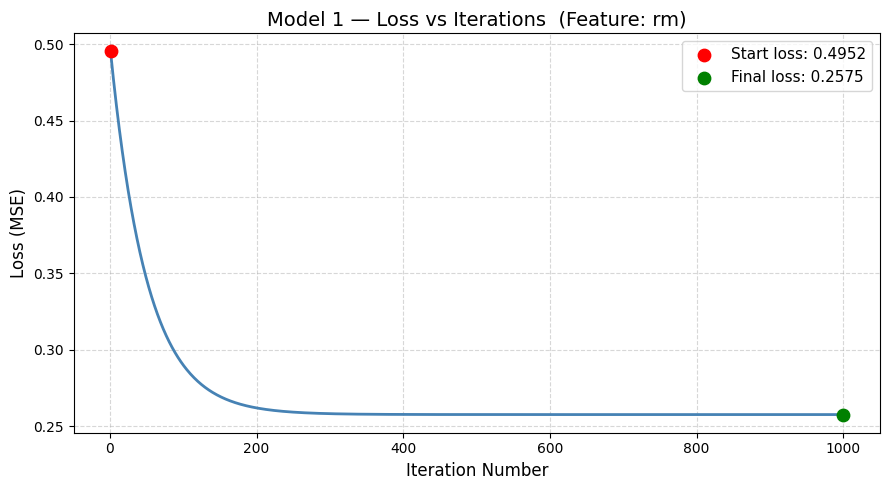

In [ ]:
# ─────────────────────────────────────────────────────────
# BLOCK 6: Model 1 — Loss vs Iterations Plot
# ─────────────────────────────────────────────────────────

plt.figure(figsize=(9, 5))

plt.plot(range(1, NUM_ITERATIONS + 1), loss_hist_m1,
         color='steelblue', linewidth=2)

# Mark the starting and ending loss
plt.scatter(1, loss_hist_m1[0], color='red', s=80, zorder=5, label=f'Start loss: {loss_hist_m1[0]:.4f}')
plt.scatter(NUM_ITERATIONS, loss_hist_m1[-1], color='green', s=80, zorder=5, label=f'Final loss: {loss_hist_m1[-1]:.4f}')

plt.xlabel('Iteration Number', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Model 1 — Loss vs Iterations  (Feature: rm)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# The loss drops fast at first (big steps) then slows down (near minimum)
# This 'elbow' shape is typical of gradient descent

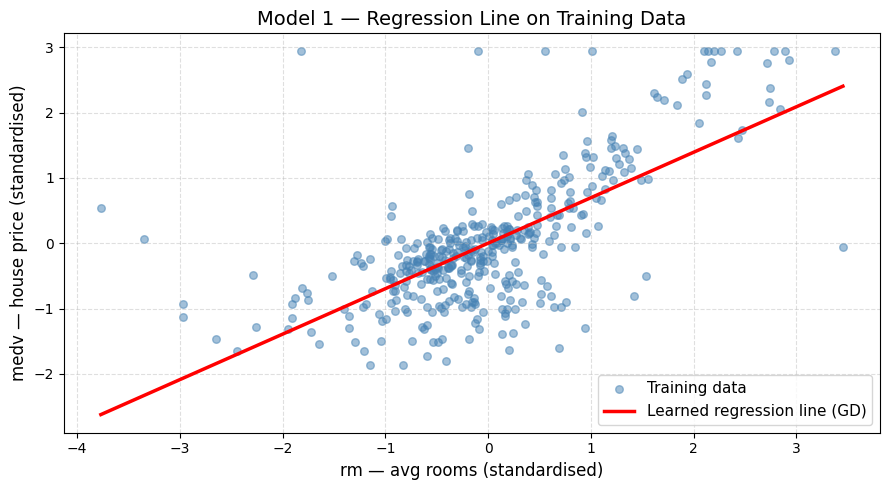

In [ ]:
# ─────────────────────────────────────────────────────────
# BLOCK 7: Model 1 — Plot the Regression Line on Data
# ─────────────────────────────────────────────────────────

# Create 100 evenly-spaced x values across the range of 'rm'
x_line = np.linspace(X_train_n1.min(), X_train_n1.max(), 100)

# Add bias column so we can multiply by theta
x_line_with_bias = np.column_stack([np.ones(100), x_line])

# Use our learned theta to predict y for this line
y_line = x_line_with_bias @ theta_gd_m1

plt.figure(figsize=(9, 5))

# Plot the actual training data points
plt.scatter(
    X_train_n1.ravel(),    # .ravel() flattens (404,1) → (404,)
    y_train_n,
    alpha=0.5, color='steelblue', s=30, label='Training data'
)

# Plot the regression line
plt.plot(x_line, y_line,
         color='red', linewidth=2.5, label='Learned regression line (GD)')

plt.xlabel('rm — avg rooms (standardised)', fontsize=12)
plt.ylabel('medv — house price (standardised)', fontsize=12)
plt.title('Model 1 — Regression Line on Training Data', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# The positive slope confirms: more rooms = higher price

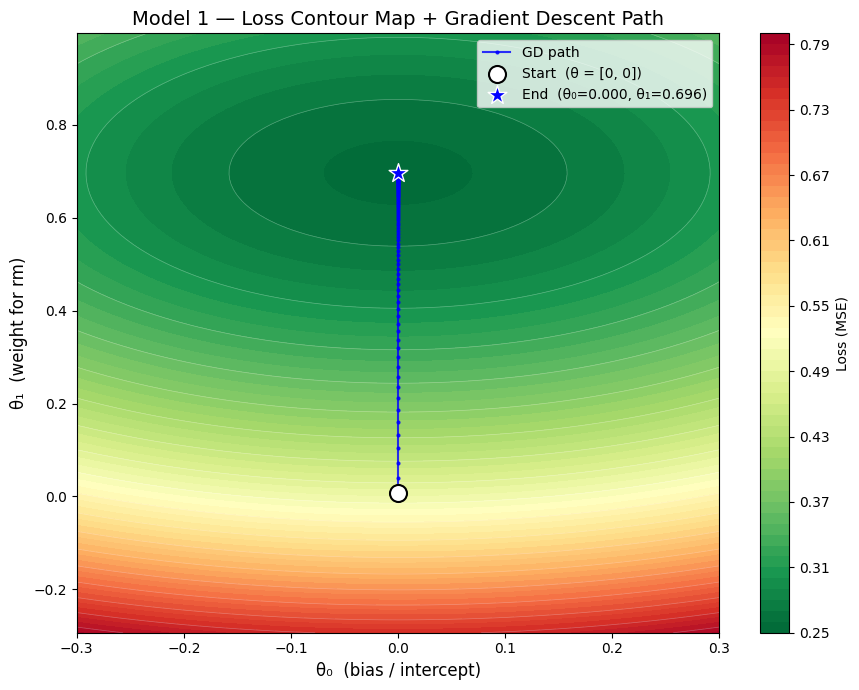

GD started at  : θ₀ = 0.0000,  θ₁ = 0.0070
GD converged to: θ₀ = 0.0000,  θ₁ = 0.6963
The path shows GD rolling down the 'bowl' shaped loss surface to the minimum.


In [ ]:
# ─────────────────────────────────────────────────────────
# BLOCK 8: Model 1 — Contour Plot + Gradient Descent Path
# ─────────────────────────────────────────────────────────
#
# A contour plot shows the LOSS SURFACE:
# - x-axis: all possible values of theta0 (intercept)
# - y-axis: all possible values of theta1 (slope for rm)
# - colour: how high the loss is at that (theta0, theta1) point
# Dark = low loss (we want to be here). Bright = high loss.
#
# We then draw the PATH that gradient descent took
# from starting point (0, 0) to the minimum.

# ── Step 1: Create a grid of (theta0, theta1) combinations ──
theta0_opt = theta_gd_m1[0]   # where GD ended up
theta1_opt = theta_gd_m1[1]

# Path start is at (0, 0) since we initialise theta = zeros
path_start_t0 = theta_hist_m1[0][0]   # first stored theta0
path_start_t1 = theta_hist_m1[0][1]   # first stored theta1

# Build grid that covers both start (0,0) and end (optimal) with margin
margin = 0.3
t0_min = min(path_start_t0, theta0_opt) - margin
t0_max = max(path_start_t0, theta0_opt) + margin
t1_min = min(path_start_t1, theta1_opt) - margin
t1_max = max(path_start_t1, theta1_opt) + margin

theta0_grid = np.linspace(t0_min, t0_max, 120)
theta1_grid = np.linspace(t1_min, t1_max, 120)

# Create a 2D grid (every combination of theta0 and theta1)
T0, T1 = np.meshgrid(theta0_grid, theta1_grid)

# ── Step 2: Compute loss at every grid point ──
# Vectorised: stack all theta combinations into one big matrix
# then compute all predictions at once (much faster than a loop)
t0_flat = T0.ravel()                          # flatten: (120×120,)
t1_flat = T1.ravel()                          # flatten: (120×120,)
theta_all = np.column_stack([t0_flat, t1_flat])   # shape: (14400, 2)

# All predictions at once: X_train_m1 (404,2) × theta_all.T (2, 14400)
preds_all = X_train_m1 @ theta_all.T              # shape: (404, 14400)

# Errors and loss for each theta combination
errors_all = preds_all - y_train_n[:, np.newaxis]
n = len(y_train_n)
losses_flat = (1 / (2*n)) * np.sum(errors_all**2, axis=0)

# Reshape back to 2D grid shape
Loss_grid = losses_flat.reshape(T0.shape)          # shape: (120, 120)

# ── Step 3: Plot ──
plt.figure(figsize=(9, 7))

# Filled contour: colour shows loss value
cp = plt.contourf(T0, T1, Loss_grid, levels=60, cmap='RdYlGn_r')
plt.colorbar(cp, label='Loss (MSE)')

# Contour lines (white, thin) for readability
plt.contour(T0, T1, Loss_grid, levels=20,
            colors='white', linewidths=0.5, alpha=0.3)

# ── Step 4: Plot the GD path ──
# theta_hist_m1 has the theta value at each iteration
theta_path = np.array(theta_hist_m1)   # shape: (1000, 2)

# Take every 5th point so the plot isn't too cluttered
path_sub = theta_path[::5]

plt.plot(
    path_sub[:, 0],   # theta0 over iterations
    path_sub[:, 1],   # theta1 over iterations
    'b.-', linewidth=1.5, markersize=4, alpha=0.8, label='GD path'
)

# Mark start and end of the path
plt.scatter(theta_path[0, 0], theta_path[0, 1],
            c='white', s=150, zorder=6,
            edgecolors='black', linewidths=1.5,
            label=f'Start  (θ = [0, 0])')

plt.scatter(theta_path[-1, 0], theta_path[-1, 1],
            c='blue', s=200, zorder=6, marker='*',
            edgecolors='white',
            label=f'End  (θ₀={theta0_opt:.3f}, θ₁={theta1_opt:.3f})')

plt.xlabel('θ₀  (bias / intercept)', fontsize=12)
plt.ylabel('θ₁  (weight for rm)', fontsize=12)
plt.title('Model 1 — Loss Contour Map + Gradient Descent Path', fontsize=14)
plt.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.show()

print(f"GD started at  : θ₀ = {theta_path[0,0]:.4f},  θ₁ = {theta_path[0,1]:.4f}")
print(f"GD converged to: θ₀ = {theta_path[-1,0]:.4f},  θ₁ = {theta_path[-1,1]:.4f}")
print("The path shows GD rolling down the 'bowl' shaped loss surface to the minimum.")

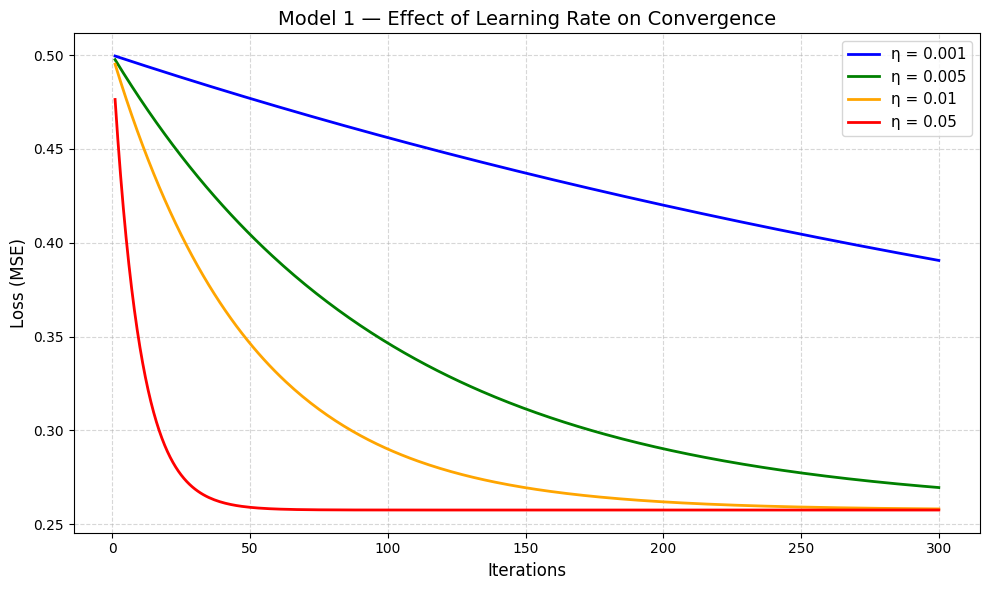


OBSERVATIONS — Effect of Learning Rate:
─────────────────────────────────────────────────────────────
η = 0.001  Too SMALL. Loss barely drops after 300 iterations.
           The model is learning but at a painfully slow pace.
           Needs thousands of iterations to converge.

η = 0.005  Still slow but noticeably better than 0.001.
           Would converge fully with more iterations.

η = 0.01   Good balance. Converges smoothly and reaches a
           low loss within 300 iterations. Recommended default.

η = 0.05   Fast convergence — reaches minimum very quickly.
           On this clean dataset it works fine. On noisy data,
           a learning rate this large can cause the loss to
           oscillate or even INCREASE (diverge) instead of drop.

Key rule: Smaller η = safer but slower. Larger η = faster but riskier.
          Always pair a small η with more iterations.
─────────────────────────────────────────────────────────────



In [ ]:
# ─────────────────────────────────────────────────────────
# BLOCK 9: Model 1 — Compare Different Learning Rates
# ─────────────────────────────────────────────────────────

learning_rates = [0.001, 0.005, 0.01, 0.05]
colors         = ['blue', 'green', 'orange', 'red']
NUM_ITER_LR    = 300    # enough iterations to see the difference clearly

plt.figure(figsize=(10, 6))

for lr, color in zip(learning_rates, colors):

    # Train a fresh model with this specific learning rate
    # (gradient_descent always initialises theta = zeros internally)
    _, loss_hist_lr, _ = gradient_descent(
        X_train_m1, y_train_n,
        learning_rate=lr,
        num_iterations=NUM_ITER_LR
    )

    plt.plot(range(1, NUM_ITER_LR + 1), loss_hist_lr,
             color=color, linewidth=2, label=f'η = {lr}')

plt.xlabel('Iterations', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Model 1 — Effect of Learning Rate on Convergence', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("""
OBSERVATIONS — Effect of Learning Rate:
─────────────────────────────────────────────────────────────
η = 0.001  Too SMALL. Loss barely drops after 300 iterations.
           The model is learning but at a painfully slow pace.
           Needs thousands of iterations to converge.

η = 0.005  Still slow but noticeably better than 0.001.
           Would converge fully with more iterations.

η = 0.01   Good balance. Converges smoothly and reaches a
           low loss within 300 iterations. Recommended default.

η = 0.05   Fast convergence — reaches minimum very quickly.
           On this clean dataset it works fine. On noisy data,
           a learning rate this large can cause the loss to
           oscillate or even INCREASE (diverge) instead of drop.

Key rule: Smaller η = safer but slower. Larger η = faster but riskier.
          Always pair a small η with more iterations.
─────────────────────────────────────────────────────────────
""")

In [ ]:
# ─────────────────────────────────────────────────────────
# BLOCK 10: Train Model 2 — 7 Features
# ─────────────────────────────────────────────────────────

print("=" * 60)
print("  MODEL 2 — 7 Features: crim, zn, rm, age, dis, tax, lstat")
print("=" * 60)

LEARNING_RATE_M2 = 0.01

start = time.time()

theta_gd_m2, loss_hist_m2, _ = gradient_descent(
    X_train_m2,
    y_train_n,
    learning_rate=LEARNING_RATE_M2,
    num_iterations=NUM_ITERATIONS
)

time_gd_m2 = time.time() - start

# Compute losses
train_loss_gd_m2 = compute_loss(X_train_m2, y_train_n, theta_gd_m2)
test_loss_gd_m2  = compute_loss(X_test_m2,  y_test_n,  theta_gd_m2)

print(f"\nLearned theta (8 values: bias + 7 features):")
labels = ['bias'] + features_m2
for label, val in zip(labels, theta_gd_m2):
    print(f"  {label:10s}: {val:+.4f}")

print(f"\nTrain Loss (MSE) : {train_loss_gd_m2:.4f}")
print(f"Test  Loss (MSE) : {test_loss_gd_m2:.4f}")
print(f"Training Time    : {time_gd_m2:.4f} seconds")

print(f"\n── Model Comparison ──")
print(f"Model1 Test Loss (1 feature)  : {test_loss_gd_m1:.4f}")
print(f"Model2 Test Loss (7 features) : {test_loss_gd_m2:.4f}")
improvement = ((test_loss_gd_m1 - test_loss_gd_m2) / test_loss_gd_m1) * 100
print(f"Improvement: {improvement:.1f}%  — Model2 is significantly better")

  MODEL 2 — 7 Features: crim, zn, rm, age, dis, tax, lstat

Learned theta (8 values: bias + 7 features):
  bias      : +0.0000
  crim      : -0.0739
  zn        : +0.1814
  rm        : +0.3524
  age       : -0.0038
  dis       : -0.2896
  tax       : -0.1779
  lstat     : -0.4642

Train Loss (MSE) : 0.1497
Test  Loss (MSE) : 0.1520
Training Time    : 0.0237 seconds

── Model Comparison ──
Model1 Test Loss (1 feature)  : 0.2125
Model2 Test Loss (7 features) : 0.1520
Improvement: 28.5%  — Model2 is significantly better


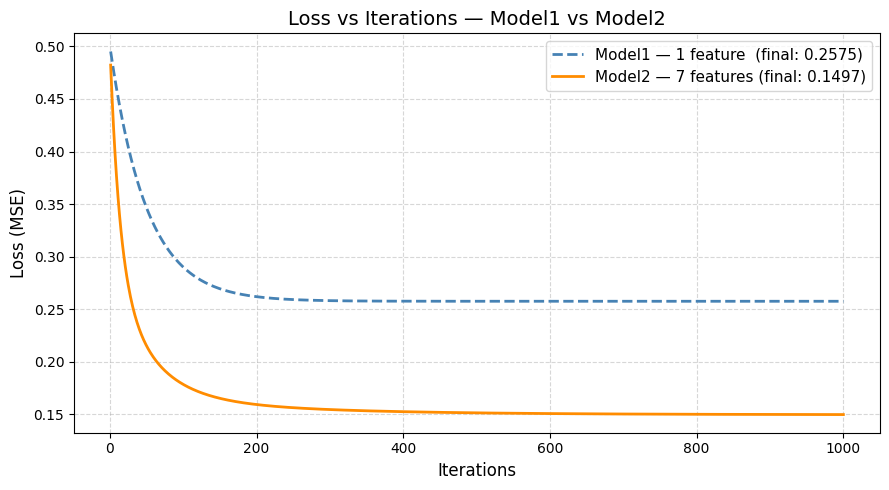

Model2 converges to a LOWER final loss because it has
access to more information (7 features vs 1).


In [ ]:
# ─────────────────────────────────────────────────────────
# BLOCK 11: Loss vs Iterations — Model1 vs Model2
# ─────────────────────────────────────────────────────────

plt.figure(figsize=(9, 5))

plt.plot(range(1, NUM_ITERATIONS + 1), loss_hist_m1,
         color='steelblue', linewidth=2, linestyle='--',
         label=f'Model1 — 1 feature  (final: {loss_hist_m1[-1]:.4f})')

plt.plot(range(1, NUM_ITERATIONS + 1), loss_hist_m2,
         color='darkorange', linewidth=2,
         label=f'Model2 — 7 features (final: {loss_hist_m2[-1]:.4f})')

plt.xlabel('Iterations', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Loss vs Iterations — Model1 vs Model2', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Model2 converges to a LOWER final loss because it has")
print("access to more information (7 features vs 1).")

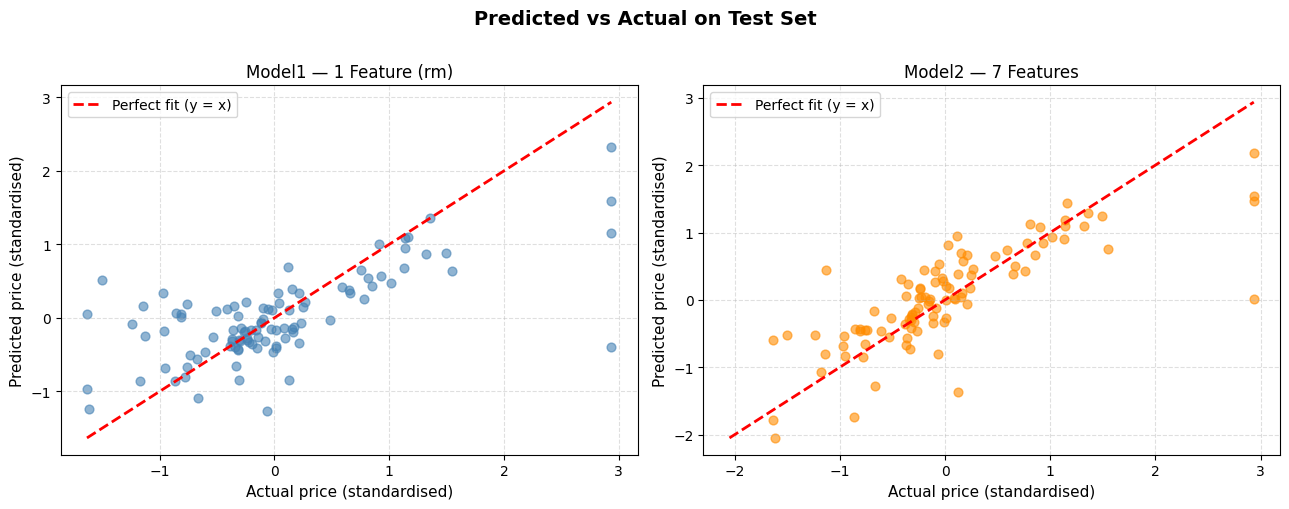

Points closer to the red line = better predictions.
Model2 clusters more tightly around the diagonal → lower test loss.


In [ ]:
# ─────────────────────────────────────────────────────────
# BLOCK 12: Predicted vs Actual — Model1 and Model2
# ─────────────────────────────────────────────────────────
#
# For multi-feature models we can't draw a 2D regression line.
# Instead: plot what the model PREDICTED vs what the ACTUAL value was.
# Perfect model → all dots sit on the diagonal y = x line.

y_pred_m1_test = X_test_m1 @ theta_gd_m1   # Model1 predictions
y_pred_m2_test = X_test_m2 @ theta_gd_m2   # Model2 predictions

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_pred, title, color in zip(
    axes,
    [y_pred_m1_test, y_pred_m2_test],
    ['Model1 — 1 Feature (rm)', 'Model2 — 7 Features'],
    ['steelblue', 'darkorange']
):
    ax.scatter(y_test_n, y_pred, alpha=0.6, color=color, s=40)

    # Draw the perfect prediction diagonal
    lo = min(y_test_n.min(), y_pred.min())
    hi = max(y_test_n.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=2, label='Perfect fit (y = x)')

    ax.set_xlabel('Actual price (standardised)', fontsize=11)
    ax.set_ylabel('Predicted price (standardised)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Predicted vs Actual on Test Set', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("Points closer to the red line = better predictions.")
print(f"Model2 clusters more tightly around the diagonal → lower test loss.")

In [ ]:
# ─────────────────────────────────────────────────────────
# BLOCK 13: Normal Equation — Both Models
# ─────────────────────────────────────────────────────────
#
# The Normal Equation computes the EXACT optimal theta
# in ONE step using matrix algebra: theta = (X^T X)^{-1} X^T y
#
# No iterations, no learning rate. Just math.

print("=" * 55)
print("  NORMAL EQUATION")
print("=" * 55)

# ── Model 1 ──
print("\n--- Model 1 (1 Feature: rm) ---")

start = time.time()
theta_ne_m1 = normal_equation(X_train_m1, y_train_n)
time_ne_m1  = time.time() - start

train_loss_ne_m1 = compute_loss(X_train_m1, y_train_n, theta_ne_m1)
test_loss_ne_m1  = compute_loss(X_test_m1,  y_test_n,  theta_ne_m1)

print(f"Normal Eq   θ₀={theta_ne_m1[0]:.6f}   θ₁={theta_ne_m1[1]:.6f}")
print(f"Gradient GD θ₀={theta_gd_m1[0]:.6f}   θ₁={theta_gd_m1[1]:.6f}")
print(f"Difference: Δθ₀={abs(theta_ne_m1[0]-theta_gd_m1[0]):.8f}  "
      f"Δθ₁={abs(theta_ne_m1[1]-theta_gd_m1[1]):.8f}")
print(f"\nTrain loss (NE): {train_loss_ne_m1:.6f}")
print(f"Test  loss (NE): {test_loss_ne_m1:.6f}")
print(f"Time taken (NE): {time_ne_m1:.6f} seconds")
print(f"Time taken (GD): {time_gd_m1:.4f} seconds")

# ── Model 2 ──
print("\n--- Model 2 (7 Features) ---")

start = time.time()
theta_ne_m2 = normal_equation(X_train_m2, y_train_n)
time_ne_m2  = time.time() - start

train_loss_ne_m2 = compute_loss(X_train_m2, y_train_n, theta_ne_m2)
test_loss_ne_m2  = compute_loss(X_test_m2,  y_test_n,  theta_ne_m2)

print(f"\nNormal Equation theta (8 values):")
for label, v_ne, v_gd in zip(['bias']+features_m2, theta_ne_m2, theta_gd_m2):
    print(f"  {label:8s}: NE={v_ne:+.6f}   GD={v_gd:+.6f}   diff={abs(v_ne-v_gd):.8f}")

print(f"\nTrain loss (NE): {train_loss_ne_m2:.6f}")
print(f"Test  loss (NE): {test_loss_ne_m2:.6f}")
print(f"Time taken (NE): {time_ne_m2:.6f} seconds")
print(f"Time taken (GD): {time_gd_m2:.4f} seconds")

  NORMAL EQUATION

--- Model 1 (1 Feature: rm) ---
Normal Eq   θ₀=0.000000   θ₁=0.696368
Gradient GD θ₀=0.000000   θ₁=0.696338
Difference: Δθ₀=0.00000000  Δθ₁=0.00003006

Train loss (NE): 0.257536
Test  loss (NE): 0.212460
Time taken (NE): 0.000390 seconds
Time taken (GD): 0.0415 seconds

--- Model 2 (7 Features) ---

Normal Equation theta (8 values):
  bias    : NE=+0.000000   GD=+0.000000   diff=0.00000000
  crim    : NE=-0.072032   GD=-0.073891   diff=0.00185897
  zn      : NE=+0.199372   GD=+0.181378   diff=0.01799449
  rm      : NE=+0.338502   GD=+0.352377   diff=0.01387455
  age     : NE=-0.001822   GD=-0.003758   diff=0.00193660
  dis     : NE=-0.313915   GD=-0.289634   diff=0.02428097
  tax     : NE=-0.184460   GD=-0.177937   diff=0.00652328
  lstat   : NE=-0.479705   GD=-0.464207   diff=0.01549796

Train loss (NE): 0.149580
Test  loss (NE): 0.152853
Time taken (NE): 0.000285 seconds
Time taken (GD): 0.0237 seconds


In [ ]:
# ─────────────────────────────────────────────────────────
# BLOCK 14: Final Comparison Table + Key Observations
# ─────────────────────────────────────────────────────────

# Build the comparison table
comparison = pd.DataFrame({
    'Method': [
        'GD  — Model1  (1 feature)',
        'NE  — Model1  (1 feature)',
        'GD  — Model2  (7 features)',
        'NE  — Model2  (7 features)'
    ],
    'Train Loss': [
        round(train_loss_gd_m1, 5),
        round(train_loss_ne_m1, 5),
        round(train_loss_gd_m2, 5),
        round(train_loss_ne_m2, 5)
    ],
    'Test Loss': [
        round(test_loss_gd_m1, 5),
        round(test_loss_ne_m1, 5),
        round(test_loss_gd_m2, 5),
        round(test_loss_ne_m2, 5)
    ],
    'Time (sec)': [
        round(time_gd_m1, 4),
        round(time_ne_m1, 6),
        round(time_gd_m2, 4),
        round(time_ne_m2, 6)
    ],
    'Remarks': [
        '1000 iterations, lr=0.01',
        'Exact closed-form solution',
        '7 features, lower error',
        'Instant exact solution'
    ]
})

print("=" * 90)
print("  COMPARISON TABLE — Gradient Descent vs Normal Equation")
print("=" * 90)
print(comparison.to_string(index=False))

print("""
─────────────────────────────────────────────────────────────────────────
KEY OBSERVATIONS:
─────────────────────────────────────────────────────────────────────────

1. NORMAL EQUATION = EXACT solution
   GD and NE give almost IDENTICAL losses.
   The tiny difference (≈ 0.00001) is just because GD didn't
   run long enough to converge perfectly. More iterations → identical.

2. NORMAL EQUATION is MUCH faster
   NE: microseconds (just one matrix operation)
   GD: milliseconds (1000 loop iterations)
   For large datasets (millions of rows), this flips — matrix
   inversion becomes very slow, so GD is preferred there.

3. MODEL2 beats MODEL1 clearly
   7 features give ~30% lower test loss than 1 feature.
   More relevant features = better predictions.

4. WHEN TO USE GRADIENT DESCENT:
   - Dataset is very large (> 100,000 rows) — NE too slow
   - Too many features (> 10,000) — matrix inversion too slow
   - Neural networks — GD is the only practical option

5. WHEN TO USE NORMAL EQUATION:
   - Small-to-medium dataset (< 50,000 rows)
   - Relatively few features (< 1,000)
   - You want guaranteed exact solution without tuning learning rate
─────────────────────────────────────────────────────────────────────────
""")

  COMPARISON TABLE — Gradient Descent vs Normal Equation
                    Method  Train Loss  Test Loss  Time (sec)                    Remarks
 GD  — Model1  (1 feature)     0.25754    0.21246    0.041500   1000 iterations, lr=0.01
 NE  — Model1  (1 feature)     0.25754    0.21246    0.000390 Exact closed-form solution
GD  — Model2  (7 features)     0.14975    0.15196    0.023700    7 features, lower error
NE  — Model2  (7 features)     0.14958    0.15285    0.000285     Instant exact solution

─────────────────────────────────────────────────────────────────────────
KEY OBSERVATIONS:
─────────────────────────────────────────────────────────────────────────

1. NORMAL EQUATION = EXACT solution
   GD and NE give almost IDENTICAL losses.
   The tiny difference (≈ 0.00001) is just because GD didn't
   run long enough to converge perfectly. More iterations → identical.

2. NORMAL EQUATION is MUCH faster
   NE: microseconds (just one matrix operation)
   GD: milliseconds (1000 loop itera